# ***Sentiment Predictor Healthcare Chatbot Using Deep Learning***

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d datatattle/covid-19-nlp-text-classification
!unzip covid-19-nlp-text-classification.zip


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/datatattle/covid-19-nlp-text-classification
License(s): copyright-authors
  0% 0.00/4.38M [00:00<?, ?B/s]
100% 4.38M/4.38M [00:00<00:00, 83.9MB/s]
Archive:  covid-19-nlp-text-classification.zip
  inflating: Corona_NLP_test.csv     
  inflating: Corona_NLP_train.csv    


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import ipywidgets as widgets
from IPython.display import display, clear_output
# Import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity



In [11]:
# Load the dataset
df = pd.read_csv("Corona_NLP_train.csv", encoding='latin1')
df.head()


,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [12]:

# Remove unnecessary columns
df = df[['OriginalTweet', 'Sentiment']]

# Convert text to lowercase
df['OriginalTweet'] = df['OriginalTweet'].str.lower()

# Encode labels
le = LabelEncoder()
df['Sentiment'] = le.fit_transform(df['Sentiment'])

# Tokenize the text
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['OriginalTweet'])
sequences = tokenizer.texts_to_sequences(df['OriginalTweet'])

# Padding sequences to make them all the same length
padded_sequences = pad_sequences(sequences, padding='post', maxlen=50)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, df['Sentiment'], test_size=0.2, random_state=42)



In [13]:
# Define the model
model = Sequential([
    Embedding(input_dim=5000, output_dim=16, input_length=50),
    LSTM(64, return_sequences=True),
    Dropout(0.5),
    LSTM(32),
    Dense(16, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 64s 56ms/step - accuracy: 0.2963 - loss: 1.5356 - val_accuracy: 0.4246 - val_loss: 1.3086
Epoch 2/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 81s 55ms/step - accuracy: 0.4635 - loss: 1.2823 - val_accuracy: 0.5521 - val_loss: 1.1399
Epoch 3/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 81s 54ms/step - accuracy: 0.5886 - loss: 1.0724 - val_accuracy: 0.6941 - val_loss: 0.8703
Epoch 4/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 55s 53ms/step - accuracy: 0.6745 - loss: 0.8978 - val_accuracy: 0.7293 - val_loss: 0.7893
Epoch 5/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.7101 - loss: 0.8318 - val_accuracy: 0.7319 - val_loss: 0.7821
Epoch 6/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 58s 56ms/step - accuracy: 0.7363 - loss: 0.7801 - val_accuracy: 0.7415 - val_loss: 0.7553
Epoch 7/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 81s 56ms/step - accuracy: 0.7494 - loss: 0.7297 - val_accuracy: 0.7284 - val_loss: 0.7624
Epoch 8/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 56s 54ms/step - accuracy: 0.7595 -

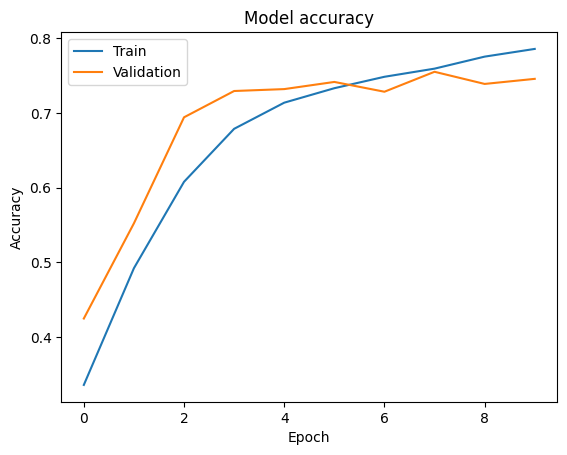

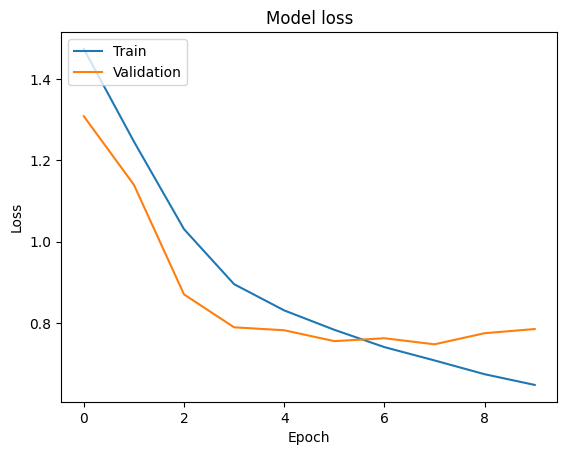

In [14]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [16]:
# Focus on Question and Answer columns
df = df[['OriginalTweet', 'Sentiment']].rename(columns={'OriginalTweet': 'Question', 'Sentiment': 'Answer'})
df.dropna(inplace=True)


# Text Preprocessing
questions = df['Question'].str.lower()
answers = df['Answer']

# Vectorize questions using TF-IDF
vectorizer = TfidfVectorizer()
question_vectors = vectorizer.fit_transform(questions)




In [17]:
def get_response(user_input):
    # Preprocess and vectorize user input
    user_input = user_input.lower()
    user_vec = vectorizer.transform([user_input])

    # Calculate cosine similarity between user input and FAQ questions
    similarity = cosine_similarity(user_vec, question_vectors)
    closest_question_index = np.argmax(similarity)

    # Get the corresponding answer
    response = answers.iloc[closest_question_index]
    return response


In [23]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from IPython.display import HTML

# Enhanced Title centered and styled
title = widgets.HTML(
    "<h1 style='text-align:center; font-size:28px; color: #4CAF50; margin-top: 10px;'>Sentiment Predictor Healthcare Chatbot</h1>"
)

# Input text area for user queries
input_text = widgets.Textarea(
    placeholder="Ask a healthcare-related question...",
    description="",
    layout=widgets.Layout(width="95%", height="100px", margin="10px auto")
)

# Prediction button styled
button_get_response = widgets.Button(
    description="Get Response",
    button_style="success",
    layout=widgets.Layout(width="200px", height="50px", margin="10px auto"),
    style={"button_color": "#4CAF50"}
)

# Output area for chatbot responses with glow effect styling
output = widgets.Output(layout=widgets.Layout(
    width="95%", height="150px", border="solid 2px #4CAF50", margin="10px auto", padding="10px", overflow="auto"
))

# Label for displaying response
response_label = widgets.HTML(
    "<div style='text-align:center; font-size:16px; color: #4CAF50; font-weight:bold; margin-top: 10px;'>Response</div>"
)

# Sample questions in card format
sample_questions = [
    "What are the symptoms of COVID-19?",
    "How can I protect myself from the virus?",
    "What should I do if I have a fever?",
    "Is it safe to travel now?",
    "How does COVID-19 spread?",
    "Are there any side effects of the vaccine?",
    "What are the quarantine guidelines?"
]

# Container for sample question cards
question_cards = widgets.HBox(layout=widgets.Layout(margin="10px auto", justify_content="center"))
sample_question_buttons = []

# Function to populate sample question into input text when clicked
def on_sample_question_click(btn):
    input_text.value = btn.description

# Create buttons for each sample question
for question in sample_questions:
    btn = widgets.Button(
        description=question,
        layout=widgets.Layout(width="200px", height="40px", margin="5px"),
        button_style="info",
        style={"button_color": "#D3E4CD"}
    )
    btn.on_click(on_sample_question_click)
    sample_question_buttons.append(btn)

question_cards.children = sample_question_buttons

# Function to get and display the response
def display_response(change):
    with output:
        clear_output()
        user_query = input_text.value
        if user_query.strip():
            response = get_response(user_query)  # Fetch response from chatbot function
            output_text = f"<p style='color: #000; font-size: 14px; padding: 10px; background: #E6F5E6; border-radius: 10px;'>{response}</p>"
            display(HTML(output_text))

# Set the button click event to get and display response
button_get_response.on_click(display_response)

# Display elements with layout adjustments and footer
footer = widgets.HTML(
    "<p style='text-align:center; font-size:small; margin-top: 10px; color: #888;'>Created by AI Innovators</p>"
)

# Main layout
app_layout = widgets.VBox([
    title,
    question_cards,  # Display sample questions as clickable buttons
    input_text,
    button_get_response,
    response_label,
    output,
    footer
])

# Styling for the entire app layout
app_layout.layout = widgets.Layout(
    padding="20px",
    border="solid 2px #4CAF50",
    width="80%",
    margin="0 auto",
    background="#F0FFF0"
)

display(app_layout)


# **HAPPY COADING**